In [1]:
# ============================================
# MODEL 3 PREPROCESSING
# Task: classify attack types
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
import joblib

In [2]:
# ----------------------------
# Load dataset
# ----------------------------
DATA_PATH = "/home/fyp_ids_e20/processed_dataset/balanced_network_data.csv"
df = pd.read_csv(DATA_PATH)

In [3]:
# ----------------------------
# Feature list
# ----------------------------
network_features = [
    "Dst Port",
    "Protocol",
    "Flow Duration",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Fwd IAT Tot",
    "Flow Pkts/s",
    "Fwd Pkts/s",
    "Bwd Pkts/s",
    "Tot Fwd Pkts",
    "Subflow Fwd Pkts",
    "Fwd Header Len",
    "Bwd Header Len",
    "Init Fwd Win Byts",
    "Init Bwd Win Byts",
    "PSH Flag Cnt",
    "RST Flag Cnt",
    "ACK Flag Cnt",
    "ECE Flag Cnt"
]

missing = [c for c in network_features if c not in df.columns]
if missing:
    print("Missing features skipped:", missing)

network_features = [c for c in network_features if c in df.columns]
print("Using", len(network_features), "features.")

Using 22 features.


In [4]:
# ----------------------------
# Clean dataset
# ----------------------------
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Label"])

In [5]:
# ----------------------------
# Keep only attacks
# ----------------------------
df_attack = df[df["Label"] != "Benign"].copy()

X = df_attack[network_features]
y = df_attack["Label"]

# convert to numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

# encode attack labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Attack classes:")
for i, c in enumerate(label_encoder.classes_):
    print(i, ":", c)

Attack classes:
0 : Bot
1 : Brute Force -Web
2 : Brute Force -XSS
3 : DDOS attack-HOIC
4 : DDOS attack-LOIC-UDP
5 : DDoS attacks-LOIC-HTTP
6 : DoS attacks-GoldenEye
7 : DoS attacks-Hulk
8 : DoS attacks-SlowHTTPTest
9 : DoS attacks-Slowloris
10 : FTP-BruteForce
11 : Infilteration
12 : SQL Injection
13 : SSH-Bruteforce


In [6]:
# ----------------------------
# Train/test split
# ----------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train_raw.shape)
print("Test:", X_test_raw.shape)

Train: (2197547, 22)
Test: (549387, 22)


In [7]:
# ----------------------------
# Scaling
# needed for LR, SVM, MLP
# ----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

In [8]:
def evaluate_multiclass(model, X_train, X_test, y_train, y_test, label_encoder, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    joblib.dump(model, f"{model_name.lower().replace(' ', '_')}_model.joblib")

    print(f"\n===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    print()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.show()

    try:
        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test)
        elif hasattr(model, "decision_function"):
            y_scores = model.decision_function(X_test)
        else:
            y_scores = None

        if y_scores is not None:
            auc = roc_auc_score(y_test, y_scores, multi_class="ovr", average="macro")
            print("ROC-AUC (macro, OVR):", auc)
    except Exception as e:
        print("ROC-AUC could not be computed:", e)

    return model

### LogisticRegression

/home/fyp_ids_e20/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/fyp_ids_e20/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== Logistic Regression =====
Accuracy: 0.9351094947641644
Macro F1: 0.6996677070096363
Weighted F1: 0.9394724091113201

Classification Report:
                          precision    recall  f1-score   support

                     Bot       0.98      1.00      0.99     57238
        Brute Force -Web       0.02      0.46      0.04       122
        Brute Force -XSS       0.02      0.89      0.04        46
        DDOS attack-HOIC       1.00      1.00      1.00    137203
    DDOS attack-LOIC-UDP       0.74      1.00      0.85       346
  DDoS attacks-LOIC-HTTP       0.99      0.97      0.98    115238
   DoS attacks-GoldenEye       0.59      0.96      0.73      8302
        DoS attacks-Hulk       0.99      0.95      0.97     92382
DoS attacks-SlowHTTPTest       0.65      0.55      0.60     27978
   DoS attacks-Slowloris       0.87      0.94      0.91      2198
          FTP-BruteForce       0.71      0.78      0.74     38671
           Infilteration       0.98      0.81      0.89     

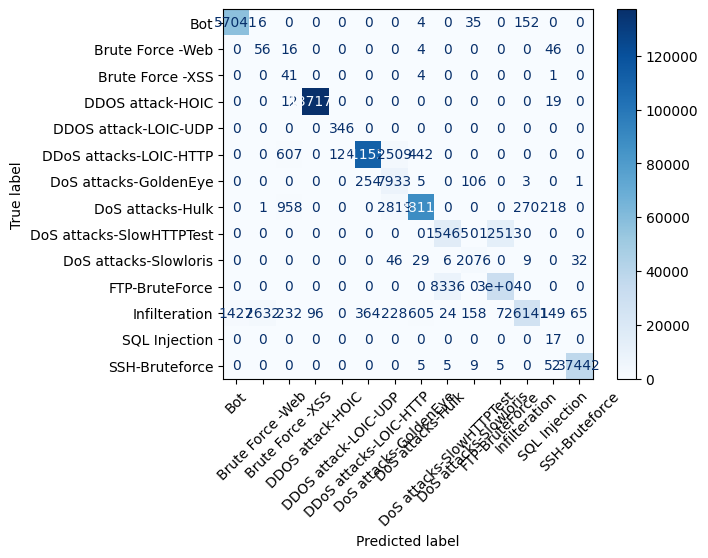

ROC-AUC (macro, OVR): 0.9943745986417233


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

evaluate_multiclass(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    label_encoder=label_encoder,
    model_name="Logistic Regression"
)

### DecisionTreeClassifier


===== Decision Tree =====
Accuracy: 0.9671178968559504
Macro F1: 0.914058644870675
Weighted F1: 0.9657036134518827

Classification Report:
                          precision    recall  f1-score   support

                     Bot       1.00      1.00      1.00     57238
        Brute Force -Web       0.94      0.93      0.93       122
        Brute Force -XSS       0.96      0.96      0.96        46
        DDOS attack-HOIC       1.00      1.00      1.00    137203
    DDOS attack-LOIC-UDP       0.87      0.84      0.86       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    115238
   DoS attacks-GoldenEye       1.00      1.00      1.00      8302
        DoS attacks-Hulk       1.00      1.00      1.00     92382
DoS attacks-SlowHTTPTest       0.77      0.52      0.62     27978
   DoS attacks-Slowloris       0.99      0.99      0.99      2198
          FTP-BruteForce       0.72      0.88      0.79     38671
           Infilteration       1.00      1.00      1.00     32128
 

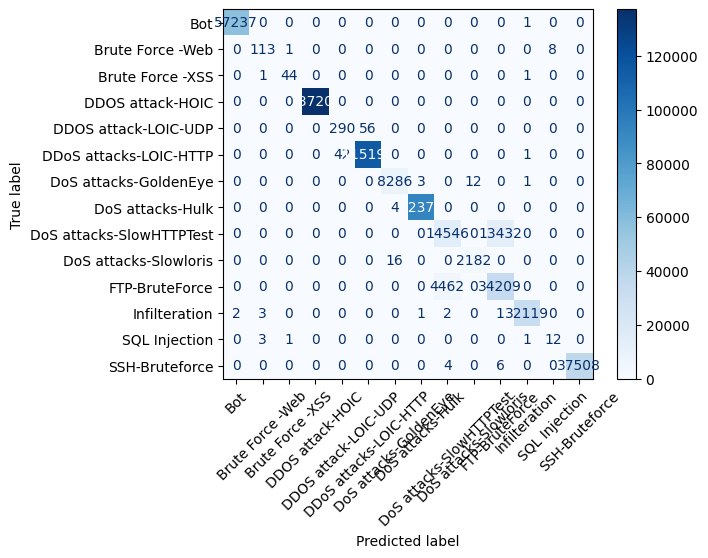

ROC-AUC (macro, OVR): 0.9785062391277367


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [9]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=None,
    class_weight="balanced",
    random_state=42
)

evaluate_multiclass(
    dt,
    X_train_raw,
    X_test_raw,
    y_train,
    y_test,
    label_encoder=label_encoder,
    model_name="Decision Tree"
)

### RandomForestClassifier


===== Random Forest =====
Accuracy: 0.9671761435927679
Macro F1: 0.9126015787910786
Weighted F1: 0.965760695446864

Classification Report:
                          precision    recall  f1-score   support

                     Bot       1.00      1.00      1.00     57238
        Brute Force -Web       0.96      0.89      0.92       122
        Brute Force -XSS       1.00      1.00      1.00        46
        DDOS attack-HOIC       1.00      1.00      1.00    137203
    DDOS attack-LOIC-UDP       0.89      0.91      0.90       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    115238
   DoS attacks-GoldenEye       1.00      1.00      1.00      8302
        DoS attacks-Hulk       1.00      1.00      1.00     92382
DoS attacks-SlowHTTPTest       0.77      0.52      0.62     27978
   DoS attacks-Slowloris       1.00      1.00      1.00      2198
          FTP-BruteForce       0.72      0.88      0.79     38671
           Infilteration       1.00      1.00      1.00     32128
 

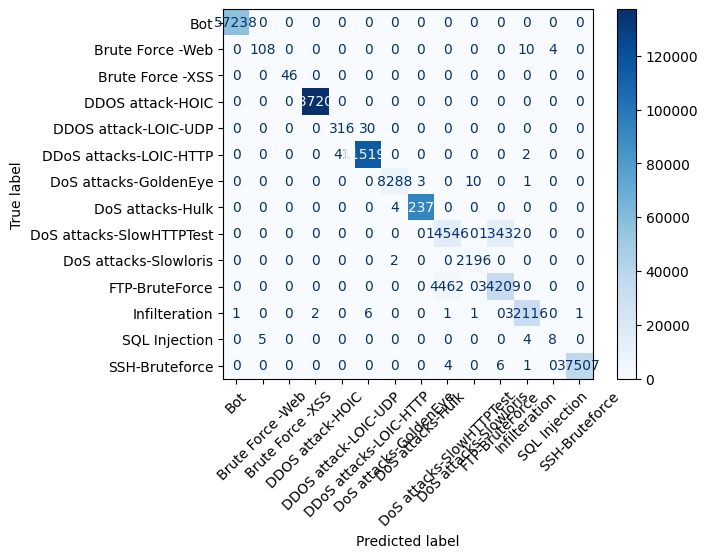

ROC-AUC (macro, OVR): 0.9981656895541674


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

evaluate_multiclass(
    rf,
    X_train_raw,
    X_test_raw,
    y_train,
    y_test,
    label_encoder=label_encoder,
    model_name="Random Forest"
)

### SVC

### XGBClassifier


===== XGBoost =====
Accuracy: 0.9671979861190745
Macro F1: 0.9237261145426261
Weighted F1: 0.9657093297738013

Classification Report:
                          precision    recall  f1-score   support

                     Bot       1.00      1.00      1.00     57238
        Brute Force -Web       0.96      0.90      0.93       122
        Brute Force -XSS       0.96      1.00      0.98        46
        DDOS attack-HOIC       1.00      1.00      1.00    137203
    DDOS attack-LOIC-UDP       0.87      0.95      0.91       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    115238
   DoS attacks-GoldenEye       1.00      1.00      1.00      8302
        DoS attacks-Hulk       1.00      1.00      1.00     92382
DoS attacks-SlowHTTPTest       0.77      0.51      0.62     27978
   DoS attacks-Slowloris       0.99      1.00      1.00      2198
          FTP-BruteForce       0.72      0.89      0.79     38671
           Infilteration       1.00      1.00      1.00     32128
      

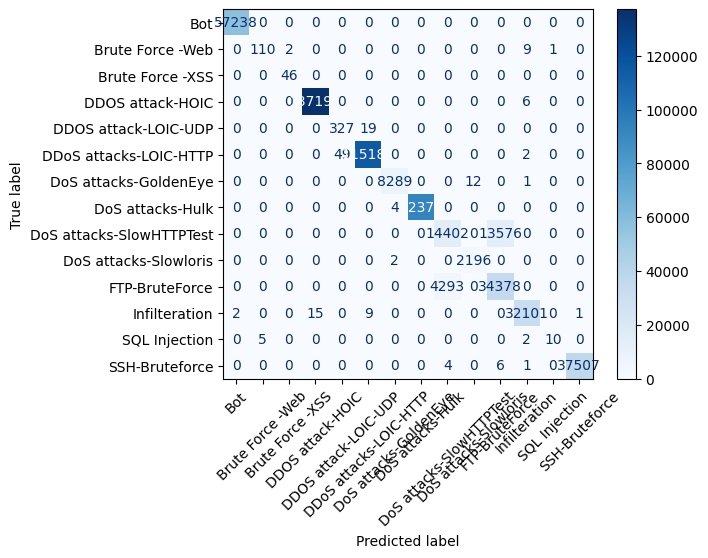

ROC-AUC (macro, OVR): 0.998167734936721


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [11]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    n_jobs=-1
)

evaluate_multiclass(
    xgb,
    X_train_raw,
    X_test_raw,
    y_train,
    y_test,
    label_encoder=label_encoder,
    model_name="XGBoost"
)

### LGBMClassifier

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078797 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3791
[LightGBM] [Info] Number of data points in the train set: 2197547, number of used features: 22
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start t

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

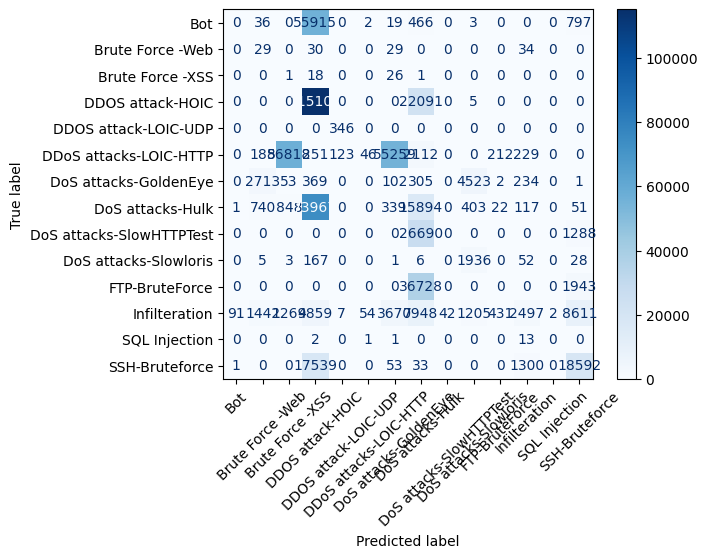

ROC-AUC (macro, OVR): 0.6030912083603595


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [12]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    class_weight="balanced",
    n_jobs=-1
)

evaluate_multiclass(
    lgbm,
    X_train_raw,
    X_test_raw,
    y_train,
    y_test,
    label_encoder=label_encoder,
    model_name="LightGBM"
)

### MLPClassifier


===== MLP Neural Network =====
Accuracy: 0.9642583461203122
Macro F1: 0.7765482094133701
Weighted F1: 0.9626813214165386

Classification Report:
                          precision    recall  f1-score   support

                     Bot       1.00      1.00      1.00     57238
        Brute Force -Web       0.69      0.77      0.73       122
        Brute Force -XSS       0.00      0.00      0.00        46
        DDOS attack-HOIC       1.00      1.00      1.00    137203
    DDOS attack-LOIC-UDP       0.76      0.96      0.85       346
  DDoS attacks-LOIC-HTTP       0.99      1.00      0.99    115238
   DoS attacks-GoldenEye       0.96      0.91      0.93      8302
        DoS attacks-Hulk       1.00      1.00      1.00     92382
DoS attacks-SlowHTTPTest       0.77      0.51      0.62     27978
   DoS attacks-Slowloris       0.97      0.98      0.97      2198
          FTP-BruteForce       0.72      0.89      0.79     38671
           Infilteration       1.00      0.99      0.99     3

/home/fyp_ids_e20/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fyp_ids_e20/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fyp_ids_e20/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


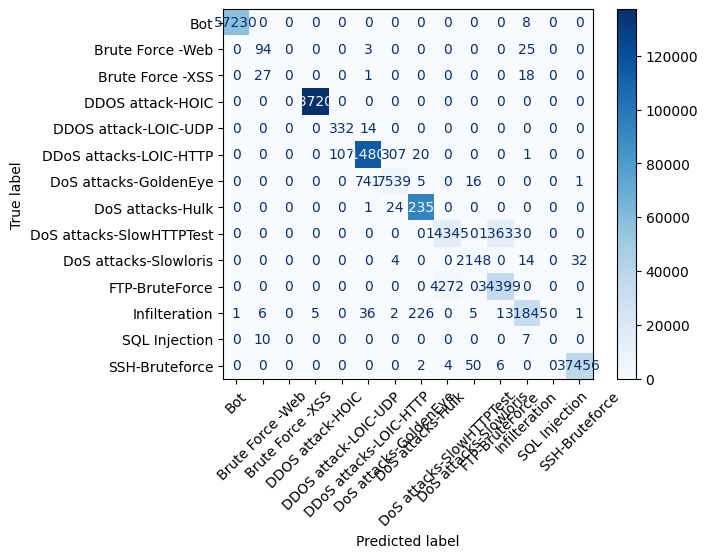

ROC-AUC (macro, OVR): 0.9979772768546137


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",50
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [10]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128,64),
    activation="relu",
    max_iter=50,
    early_stopping=True
)

evaluate_multiclass(
    mlp,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    label_encoder=label_encoder,
    model_name="MLP Neural Network"
)